In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sumo_rl
import random
from collections import deque
from sumo_rl.environment.observations import ObservationFunction
from gymnasium import spaces
from pathlib import Path

In [2]:
net_path = "./cross.net.xml"
route = "./cross.rou.xml"

In [3]:
import traci

def evaluate_baseline():
    print("Running Baseline (Fixed-Time) Simulation...")
    
    # Start SUMO directly (No sumo_rl wrapper)
    sumo_cmd = [
        "sumo", # Use "sumo-gui" if you want to watch it visually
        "-n", net_path,
        "-r", route, # Make sure this variable holds your route files
        "--step-length", "5",
        "--tripinfo-output", "baseline_tripinfo.xml", # <-- Save baseline metrics
        "-W"
    ]
    
    traci.start(sumo_cmd)
    
    # Run the simulation until all cars have left or we hit 1800 seconds
    step = 0
    while traci.simulation.getMinExpectedNumber() > 0 and step < 1800:
        traci.simulationStep()
        step += 5
        
    traci.close()
    print("Baseline Simulation Finished!")

evaluate_baseline()

Running Baseline (Fixed-Time) Simulation...
 Retrying in 1 seconds
Step #1800.00 (1ms ~= 5000.00*RT, ~52000.00UPS, TraCI: 1ms, vehicles TOT 644 ACT 52 BUF 0)
Baseline Simulation Finished!


In [4]:
act_path = "map_actuated.net.xml"

def evaluate_baseline():
    print("Running Baseline (Fixed-Time) Simulation...")
    
    # Start SUMO directly (No sumo_rl wrapper)
    sumo_cmd = [
        "sumo", # Use "sumo-gui" if you want to watch it visually
        "-n", act_path,
        "-r", route, # Make sure this variable holds your route files
        "--step-length", "5",
        "--tripinfo-output", "actuated_tripinfo.xml", # <-- Save baseline metrics
        "-W"
    ]
    
    traci.start(sumo_cmd)
    
    # Run the simulation until all cars have left or we hit 1800 seconds
    step = 0
    while traci.simulation.getMinExpectedNumber() > 0 and step < 1800:
        traci.simulationStep()
        step += 5
        
    traci.close()
    print("Baseline Simulation Finished!")

evaluate_baseline()

Running Baseline (Fixed-Time) Simulation...
 Retrying in 1 seconds
Step #1800.00 (1ms ~= 5000.00*RT, ~51000.00UPS, TraCI: 0ms, vehicles TOT 644 ACT 51 BUF 0)
Baseline Simulation Finished!


In [5]:
def run_random_baseline():
    print("Running Random Agent Baseline...")
    
    # Use your original network and route files
    env = sumo_rl.parallel_env(
        net_file=net_path,
        route_file=route,
        use_gui=False,
        num_seconds=1800,
        delta_time=5,
        additional_sumo_cmd="--tripinfo-output random_tripinfo.xml"
    )

    observations, infos = env.reset()
    total_random_reward = 0
    
    while env.agents:
        actions = {}
        for agent in env.agents:
            # Randomly sample an action from the available action space
            actions[agent] = env.action_space(agent).sample()

        observations, rewards, terminations, truncations, infos = env.step(actions)

        for agent in rewards:
            total_random_reward += rewards[agent]

    print(f"Random Simulation Finished. Total Reward: {total_random_reward:.2f}")
    env.close()

run_random_baseline()

Running Random Agent Baseline...
 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 6ms, vehicles TOT 0 ACT 0 BUF 0)                      
 Retrying in 1 seconds
Random Simulation Finished. Total Reward: -1.57
Step #1800.00 (0ms ?*RT. ?UPS, TraCI: 47ms, vehicles TOT 645 ACT 61 BUF 0)                


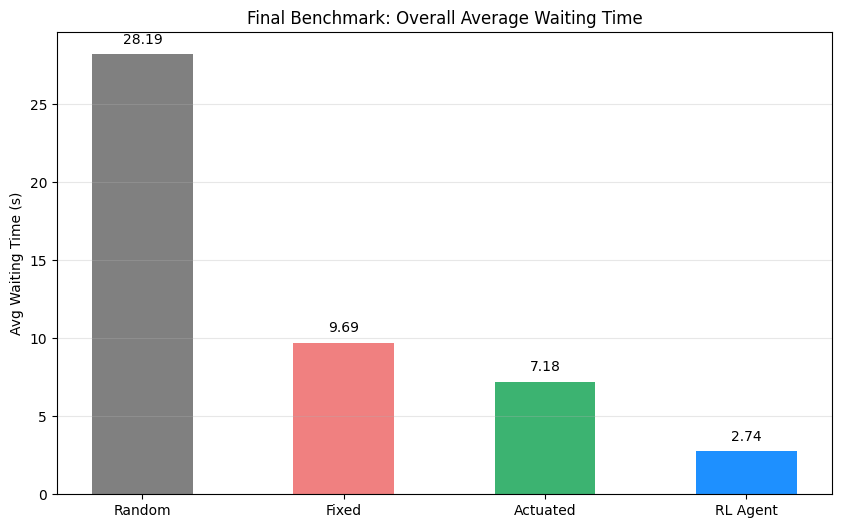

In [9]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import numpy as np

def analyze_tripinfo(file_path):
    try:
        tree = ET.parse(file_path)
        root = tree.getroot()
    except Exception:
        # Return 0 if file is not found or fails to parse
        return 0.0 
    
    wait_times = []
    # Loop through every tripinfo tag regardless of vehicle type
    for trip in root.findall('tripinfo'):
        # Extract the waitingTime attribute
        wait_time = float(trip.get('waitingTime', 0))
        wait_times.append(wait_time)
            
    # Calculate the overall average
    return sum(wait_times) / len(wait_times) if wait_times else 0.0

# Parse all four results
rl_metrics = analyze_tripinfo('tripinfo_eval.xml')
fixed_metrics = analyze_tripinfo('baseline_tripinfo.xml')
actuated_metrics = analyze_tripinfo('actuated_tripinfo.xml')
random_metrics = analyze_tripinfo('random_tripinfo.xml')

# Prepare data for the plot
labels = ['Random', 'Fixed', 'Actuated', 'RL Agent']
values = [random_metrics, fixed_metrics, actuated_metrics, rl_metrics]
colors = ['gray', 'lightcoral', 'mediumseagreen', 'dodgerblue']

fig, ax = plt.subplots(figsize=(10, 6))

# Plot a single bar for each simulation run
bars = ax.bar(labels, values, color=colors, width=0.5)

ax.set_ylabel('Avg Waiting Time (s)')
ax.set_title('Final Benchmark: Overall Average Waiting Time')

# Add the exact value labels on top of each bar for clarity
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.5, round(yval, 2), ha='center', va='bottom')

plt.grid(axis='y', alpha=0.3)
plt.show()

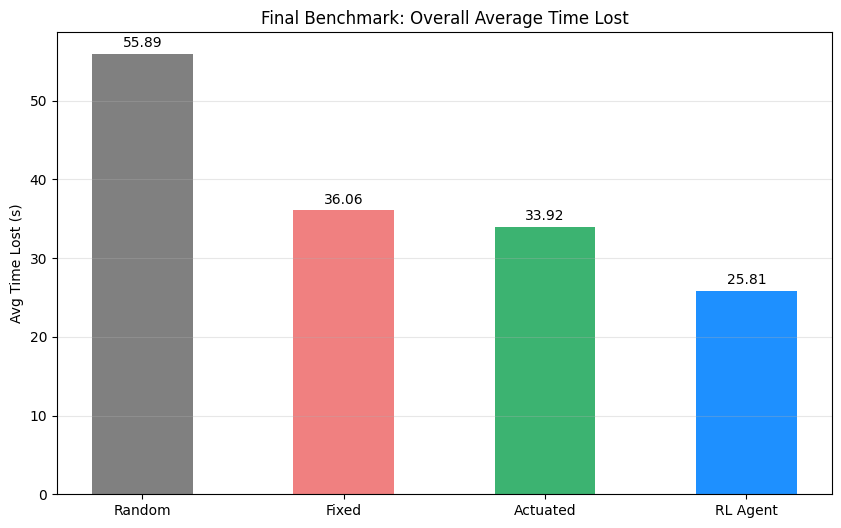

In [10]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import numpy as np

def analyze_tripinfo(file_path):
    try:
        tree = ET.parse(file_path)
        root = tree.getroot()
    except Exception:
        # Return 0.0 if file is not found or fails to parse
        return 0.0 
    
    time_losses = []
    
    # Loop through every tripinfo tag regardless of vehicle type
    for trip in root.findall('tripinfo'):
        # Extract the timeLoss attribute
        time_lost = float(trip.get('timeLoss', 0)) 
        time_losses.append(time_lost)
            
    # Calculate the overall average time loss
    return sum(time_losses) / len(time_losses) if time_losses else 0.0

# Parse all four results
rl_metrics = analyze_tripinfo('tripinfo_eval.xml')
fixed_metrics = analyze_tripinfo('baseline_tripinfo.xml')
actuated_metrics = analyze_tripinfo('actuated_tripinfo.xml')
random_metrics = analyze_tripinfo('random_tripinfo.xml')

# Prepare data for the plot
labels = ['Random', 'Fixed', 'Actuated', 'RL Agent']
values = [random_metrics, fixed_metrics, actuated_metrics, rl_metrics]
colors = ['gray', 'lightcoral', 'mediumseagreen', 'dodgerblue']

fig, ax = plt.subplots(figsize=(10, 6))

# Plot a single bar for each simulation run
bars = ax.bar(labels, values, color=colors, width=0.5)

ax.set_ylabel('Avg Time Lost (s)')
ax.set_title('Final Benchmark: Overall Average Time Lost')

# Add the exact numerical values on top of each bar for readability
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.5, round(yval, 2), ha='center', va='bottom')

plt.grid(axis='y', alpha=0.3)
plt.savefig('benchmark.png')
plt.show()